# 01 Territorial and Geologic Context

**Series:** Tribal Soils and Geology                   
**Author:** Lilly Jones, PhD, Daear Consulting                
**Primary Focus:** Pine Ridge (Oglala Lakota) and Rosebud (Sicangu Lakota), Oceti Sakowin

## Setting the Stage

Pine Ridge and Rosebud Reservations lie in the physiographic transition zone
between the Missouri Plateau (part of the Great Plains) and the Black Hills
uplift. This position determines everything about the
geology, soils, water, and landscape of these lands.

The reservations sit on the western flank of the Williston Basin structural
province. Regional dip carries strata gently eastward off the Black Hills
uplift, producing a predictable sequence from older, deeper formations in the
west to younger, shallower units in the east. The Pierre Shale, one of the
most extensive units in North America, forms the dominant near-surface
geology across most of both reservations.

This notebook establishes the spatial and stratigraphic framework that all
subsequent notebooks build on. It is the entry point for geologists unfamiliar
with the region and for Tribal scientists and community members who want to
understand their lands in a geologic context.

In [ ]:
# Imports
import sys
from pathlib import Path
REPO_ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent/"src").is_dir() and (parent/"config"/"config.yaml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from the tribal-soils-geology repository or a subdirectory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import yaml
from shapely.geometry import box
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB,
    REPO_ROOT as _REPO_ROOT, OUTPUTS_DIR, FIGURES_DIR,
    PINE_RIDGE_BBOX, ROSEBUD_BBOX, COMBINED_BBOX, STUDY_BBOX,WSD_STRATIGRAPHY,
    WSD_KEY_UNITS,
    WSD_3D_MODEL,
)

from src.loaders import (
    load_tribal_boundaries, load_state_geology, load_nhd_flowlines, load_all_oceti_sakowin
)
from src.sovereignty import print_data_acknowledgment, generate_citations, attach_provenance
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT/"config"/"config.yaml") as f:
    CONFIG = yaml.safe_load(f)
TEAL = "#007A6E"; TEAL_LT = "#E0F4F2"; GRAY = "#566573"
def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge", "Rosebud"])
print(f"Environment ready. Primary nations: {len(primary)}")

Environment ready. Primary nations: 2


In [ ]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["census_aiannh", "usgs_3d_model"])

TRIBAL SOILS AND GEOLOGY DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin, the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pract

## Tribal Boundaries and Study Area

In [ ]:
# Load Pine Ridge and Rosebud boundaries
primary = load_tribal_boundaries(["Pine Ridge", "Rosebud"])
oceti   = load_all_oceti_sakowin()

print(f"Primary nations: {len(primary)}")
for _, row in primary.iterrows():
    print(f"  {row['common_name']}: {row['area_km2']:,.0f} km²")
print(f"\nOceti Sakowin nations loaded: {len(oceti)}")
print(oceti[["NAME","common_name","area_km2"]].to_string(index=False))

Primary nations: 2
  Oglala Lakota: 11,275 km²
  Sicangu Lakota (Rosebud): 5,427 km²

Oceti Sakowin nations loaded: 8
          NAME              common_name     area_km2
Cheyenne River     Cheyenne River Sioux 11445.303666
    Crow Creek         Crow Creek Sioux  1194.914756
     Flandreau   Flandreau Santee Sioux     9.060057
 Lake Traverse  Sisseton Wahpeton Oyate  3907.473036
   Lower Brule        Lower Brule Sioux  1008.953689
    Pine Ridge            Oglala Lakota 11275.039648
       Rosebud Sicangu Lakota (Rosebud)  5427.443984
 Standing Rock      Standing Rock Sioux  9486.078416


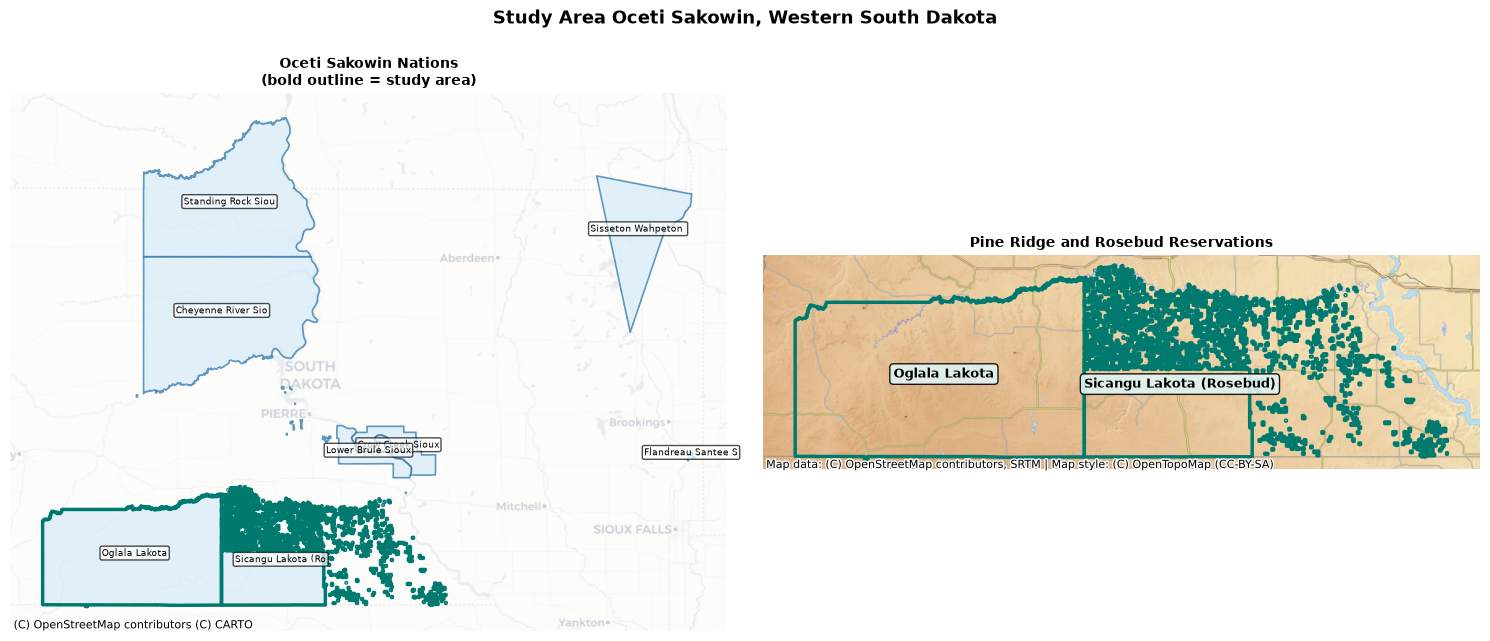

Saved: figures/01_study_area.png


In [ ]:
# Regional overview map Tribal boundaries in physiographic context
import contextily as ctx

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: Oceti Sakowin context
ax = axes[0]
oceti.to_crs(CRS_WEB).plot(ax=ax, facecolor="#D6EAF8", edgecolor="#2471A3",
                            linewidth=1.2, alpha=0.7)
primary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                              linewidth=2.5)
for _, row in oceti.iterrows():
    c = row.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs=CRS_GEOGRAPHIC).to_crs(CRS_WEB).iloc[0]
    name = row.get("common_name") or row["NAME"]
    ax.annotate(name[:18], (c3857.x, c3857.y), ha="center", fontsize=6.5,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.5)
except Exception:
    pass
ax.set_axis_off()
ax.set_title("Oceti Sakowin Nations\n(bold outline = study area)",
             fontsize=10, fontweight="bold")

# Right: Pine Ridge and Rosebud detail
ax = axes[1]
primary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                              linewidth=2.5)
for _, row in primary.iterrows():
    c = row.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs=CRS_GEOGRAPHIC).to_crs(CRS_WEB).iloc[0]
    ax.annotate(row["common_name"], (c3857.x, c3857.y), ha="center", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=TEAL_LT, alpha=0.9))
try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.7, zoom=9)
except Exception:
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, alpha=0.7)
    except Exception:
        pass
ax.set_axis_off()
ax.set_title("Pine Ridge and Rosebud Reservations",
             fontsize=10, fontweight="bold")

plt.suptitle("Study Area Oceti Sakowin, Western South Dakota",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_study_area.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_study_area.png")

## Physiographic and Structural Setting

Western South Dakota lies within the northern Great Plains physiographic
province. The study area spans the transition between three structural domains:

**The Black Hills Uplift** is a domal anticline exposing Precambrian rocks at
its core. The regional eastward dip off this uplift controls the depth and
geometry of every formation across Pine Ridge and Rosebud.

**The Missouri Plateau** is the high plains surface, primarily underlain by
the Pierre Shale and capped by Cretaceous and Paleogene units. Most of Pine
Ridge and Rosebud occupies this terrain.

**The White River Badlands** are the deeply dissected eastern escarpment where
the White River Group (Oligocene) overlies the Pierre Shale. The Badlands
form the northeastern boundary of Pine Ridge. Their striking topography is
the erosional expression of the stratigraphic boundary between these two units.

In [ ]:
# Stream network shows drainage architecture controlled by geology
print("Loading drainage network...")
streams_pr = load_nhd_flowlines(PINE_RIDGE_BBOX, min_stream_order=2)
streams_rb = load_nhd_flowlines(ROSEBUD_BBOX, min_stream_order=2)

if not streams_pr.empty:
    print(f"Pine Ridge streams (order ≥ 2): {len(streams_pr)}")
if not streams_rb.empty:
    print(f"Rosebud streams (order ≥ 2): {len(streams_rb)}")

Loading drainage network...
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 4000)
  Fetched 2000 features (offset 6000)
  Fetched 2000 features (offset 8000)
  Fetched 2000 features (offset 10000)
  Fetched 2000 features (offset 12000)
  Fetched 2000 features (offset 14000)
  Fetched 2000 features (offset 16000)
  Fetched 2000 features (offset 18000)
  Fetched 2000 features (offset 20000)
  Fetched 2000 features (offset 0)
  Fetched 2000 features (offset 2000)
  Fetched 2000 features (offset 4000)
  Fetched 2000 features (offset 6000)
  Fetched 2000 features (offset 8000)
  Fetched 2000 features (offset 10000)
  Fetched 2000 features (offset 12000)
  Fetched 2000 features (offset 14000)
  Fetched 2000 features (offset 16000)
  Fetched 2000 features (offset 18000)
  Fetched 2000 features (offset 20000)
  Fetched 1186 features (offset 22000)
Total stream segme

## Regional Stratigraphic Column

The following stratigraphic units are present across the study area, from
youngest (surface) to oldest (deepest). This column is derived from the
Spangler (2024) 3D model 25 units modeled from surface to Precambrian
basement.

Units marked with + are of particular significance for land and water
management on Pine Ridge and Rosebud.

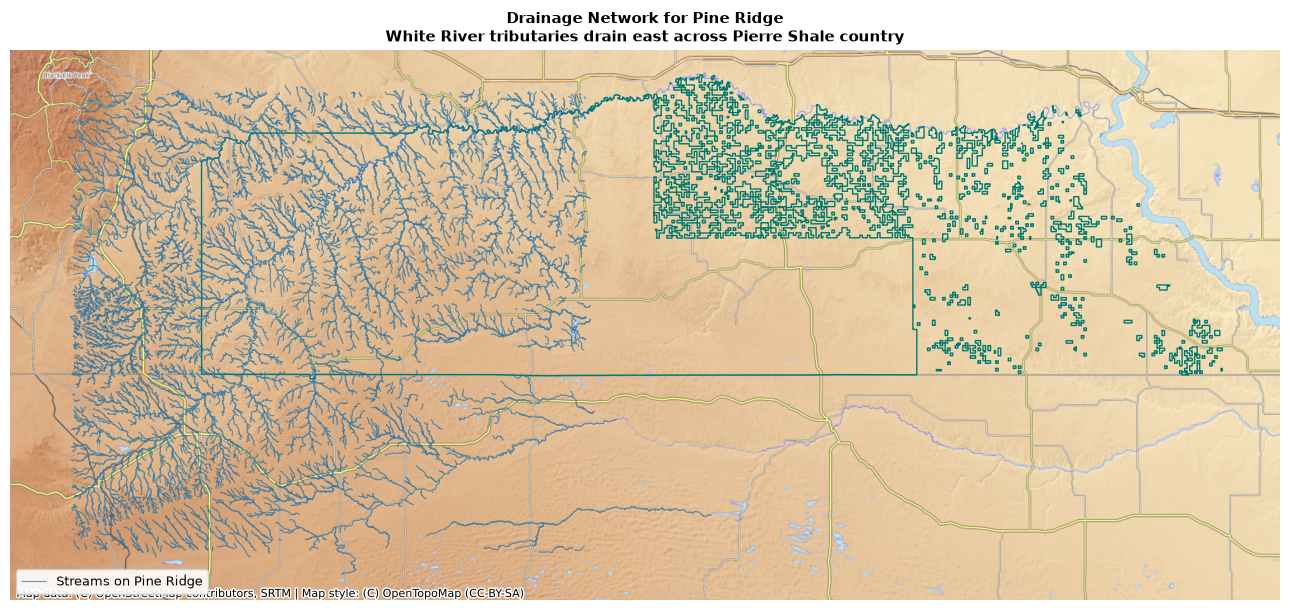

In [ ]:
# Hydrologic context map
fig, ax = plt.subplots(figsize=(13, 9))

primary_boundary = primary.dissolve()
primary_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                       linewidth=1.0, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams on Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

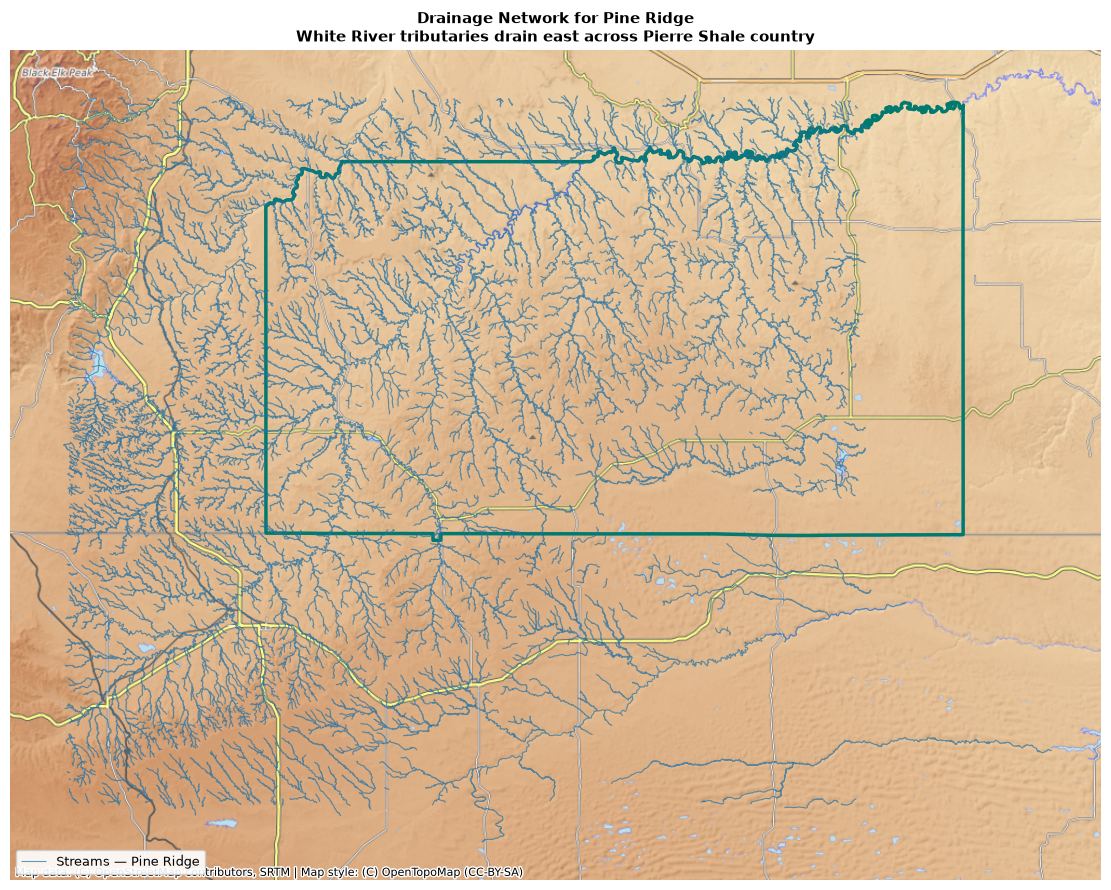

In [ ]:
pine_ridge_boundary = load_tribal_boundaries(["Pine Ridge"])
fig, ax = plt.subplots(figsize=(13, 9))

pine_ridge_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                          linewidth=2.5, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams — Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

23186
  Fetched 2000 features (offset 0)
Total stream segments: 2,000
Named streams only: 2,000 segments
Named streams present:
gnis_name
Dry Creek                  104
Cheyenne River              89
Horsehead Creek             76
White River                 74
Rush Creek                  61
French Creek                43
Cottonwood Creek            43
South Black Banks Creek     42
Bear-in-the-Lodge Creek     41
Battle Creek                33
Beef Creek                  33
Duck Creek                  30
Spring Creek                29
Lone Well Creek             27
Sand Creek                  27
North Black Banks Creek     26
White Clay Creek            26
Fisher Creek                25
Tahc’a Okute Wakpa          25
Cedar Creek                 25


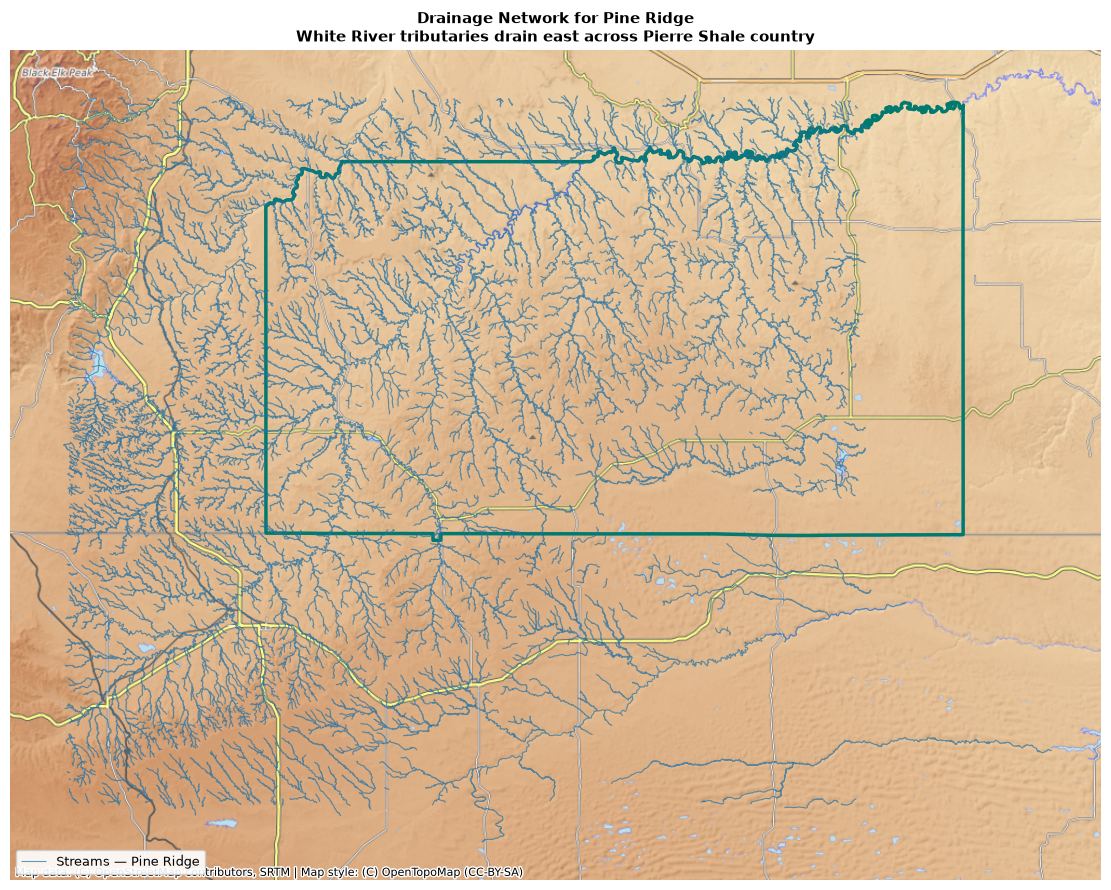

In [ ]:
# streams_pr = load_nhd_flowlines(PINE_RIDGE_BBOX, min_stream_order=2, force_refresh=True)
print(len(streams_pr))
streams_named = load_nhd_flowlines(PINE_RIDGE_BBOX, named_only=True)
print(f"Named streams only: {len(streams_named):,} segments")
print("Named streams present:")
print(streams_named["gnis_name"].value_counts().head(20).to_string())

pine_ridge_boundary = load_tribal_boundaries(["Pine Ridge"])
fig, ax = plt.subplots(figsize=(13, 9))

pine_ridge_boundary.to_crs(CRS_WEB).plot(ax=ax, facecolor="none", edgecolor=TEAL,
                                          linewidth=2.5, zorder=3)

if not streams_pr.empty:
    streams_pr.to_crs(CRS_WEB).plot(ax=ax, color="#2471A3", linewidth=0.8,
                                     alpha=0.7, zorder=4, label="Streams — Pine Ridge")

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, alpha=0.65, zoom=9)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "Drainage Network for Pine Ridge\n"
    "White River tributaries drain east across Pierre Shale country",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_drainage_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Print the stratigraphic column with management significance flags
print("REGIONAL STRATIGRAPHIC COLUMN for Western South Dakota")
print("Pine Ridge and Rosebud study area | Spangler (2024)")
print(f"{'Unit':<35} {'Significance'}")

for unit in WSD_STRATIGRAPHY:
    note = WSD_KEY_UNITS.get(unit, "")
    star = "+ " if note else "  "
    print(f"  {star}{unit:<33} {note[:50] if note else ''}")

print()
print("+ = significant for land and water management")
print()
print("Source: Spangler, L.R., 2024.")
print(f"DOI: {WSD_3D_MODEL['doi']}")
print(f"License: {WSD_3D_MODEL['license']}")

REGIONAL STRATIGRAPHIC COLUMN for Western South Dakota
Pine Ridge and Rosebud study area | Spangler (2024)
Unit                                Significance
    Glacial sediments                 
  + Ogallala Group                    Primary aquifer for Pine Ridge and Rosebud Arikare
  + Hell Creek Formation              Near-surface on eastern portion paleontological re
    Lance Formation                   
    Fox Hills Formation               
  + Pierre Shale                      Expansive clay controls slope instability, swellin
  + Niobrara Formation                Fractured chalk secondary aquifer in some areas
    Carlile Shale                     
    Greenhorn Formation               
    Mowry Shale                       
    Belle Fourche Shale               
    Morrison Formation                
    Sundance Formation                
    Inyan Kara Group                  
    Minnelusa Formation               
    Minnekahta Formation              
    Spearfish Formation

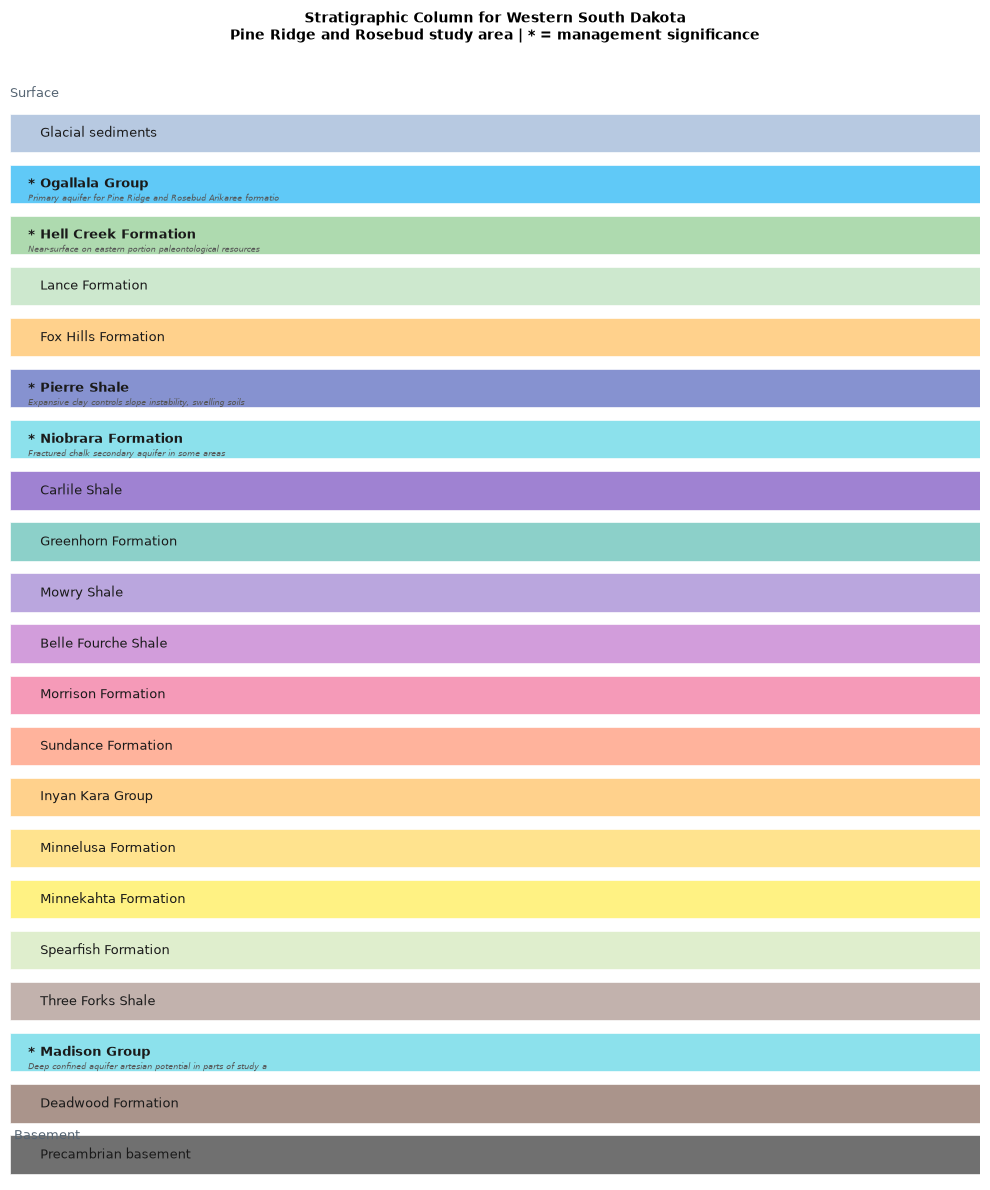

Saved: figures/01_stratigraphic_column.png


In [ ]:
# Visualize stratigraphic column as a graphic
fig, ax = plt.subplots(figsize=(10, 12))

# Color scheme by era/significance
unit_colors = {
    "Glacial sediments":      "#B0C4DE",
    "Ogallala Group":         "#4FC3F7",   # water blue
    "Hell Creek Formation":   "#A5D6A7",
    "Lance Formation":        "#C8E6C9",
    "Fox Hills Formation":    "#FFCC80",
    "Pierre Shale":           "#7986CB",   # distinctive purple
    "Niobrara Formation":     "#80DEEA",
    "Carlile Shale":          "#9575CD",
    "Greenhorn Formation":    "#80CBC4",
    "Mowry Shale":            "#B39DDB",
    "Belle Fourche Shale":    "#CE93D8",
    "Morrison Formation":     "#F48FB1",
    "Sundance Formation":     "#FFAB91",
    "Inyan Kara Group":       "#FFCC80",
    "Minnelusa Formation":    "#FFE082",
    "Minnekahta Formation":   "#FFF176",
    "Spearfish Formation":    "#DCEDC8",
    "Three Forks Shale":      "#BCAAA4",
    "Madison Group":          "#80DEEA",   # water blue
    "Deadwood Formation":     "#A1887F",
    "Precambrian basement":   "#616161",
}

n = len(WSD_STRATIGRAPHY)
bar_height = 0.75

for i, unit in enumerate(WSD_STRATIGRAPHY):
    y = n - i - 1
    color = unit_colors.get(unit, "#E0E0E0")
    ax.barh(y, 8, left=0, height=bar_height, color=color, alpha=0.9,
            edgecolor="white", linewidth=0.5)
    note = WSD_KEY_UNITS.get(unit, "")
    star = "* " if note else "   "
    label = f"{star}{unit}"
    ax.text(0.15, y, label, va="center", ha="left", fontsize=9, fontweight="bold"
            if note else "normal", color="#1a1a1a")
    if note:
        ax.text(0.15, y - 0.28, note[:60], va="center", ha="left",
                fontsize=6, color="#555555", style="italic")

ax.set_xlim(0, 8)
ax.set_ylim(-0.5, n + 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

ax.annotate("Surface ", xy=(0, n - 0.3), fontsize=9, color=GRAY,
            ha="left")
ax.annotate(" Basement", xy=(0, 0.3), fontsize=9, color=GRAY,
            ha="left")

ax.set_title(
    "Stratigraphic Column for Western South Dakota\n"
    "Pine Ridge and Rosebud study area | * = management significance",
    fontsize=10, fontweight="bold", pad=12
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"01_stratigraphic_column.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_stratigraphic_column.png")

## Summary

This notebook established the spatial and stratigraphic framework for the
series. Key takeaways for the notebooks that follow:

- Pine Ridge and Rosebud occupy the eastern flank of the Black Hills uplift
  and the Missouri Plateau structurally simple, but with regionally
  significant stratigraphy
- The Pierre Shale is the dominant near-surface formation across most of both
  reservations its expansive clay mineralogy (smectite) controls slope
  stability, soil behavior, and road engineering conditions (notebook 07)
- The Ogallala Group (Arikaree aquifer) is the primary water supply for both
  reservations its thickness and depth vary systematically across the study
  area (notebook 08)
- The 3D model (Spangler 2024) provides the subsurface horizon data that
  makes quantitative analysis of depth-to-formation possible for the first
  time in a Tribal land context (notebook 04)
- Stream drainage follows the regional dip and the White River system the
  surface hydrology reflects the same structural control as the stratigraphy

**Next:** Notebook 02 covers surficial geology the Quaternary deposits that
directly underlie the soils and control near-surface engineering behavior.

In [ ]:
# Print citations
print(generate_citations(["usgs_3d_model", "census_aiannh"]))

DATA CITATIONS

USGS 3D Geological Model of Western South Dakota
  Spangler, L.R., 2024, Digital data for a 3D Geological Model of western South Dakota, USA: U.S. Geological Survey data release, https://doi.org/10.5066/P9LK4QHJ.
  https://doi.org/10.5066/P9LK4QHJ
  Steward: US Geological Survey, Rocky Mountain Region | License: CC0 1.0 Universal (Public Domain)

US Census Bureau TIGER/Line AIANNH Boundaries
  US Census Bureau. TIGER/Line Shapefiles: American Indian / Alaska Native / Native Hawaiian Areas (AIANNH). https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
  https://www.census.gov/geographies/mapping-files/
  Steward: US Census Bureau | License: Public domain

TERRITORIAL PROVENANCE
  1868 Fort Laramie Treaty Oceti Sakowin territory, including the Great Sioux Reservation
  The lands of Pine Ridge and Rosebud Reservations are the sovereign territory of the Oglala Lakota and Sicangu Lakota peoples respectively. Federal and state geological surve